In [1]:
#Installing kaggle library
#Uploading kaggle.json file (token to connect to kaggle)
!pip install kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanjaldir","key":"cb91ac02c819a45f54ad9446b7b44eb7"}'}

In [2]:
#Moving kaggle.json file to correct location
#Setting appropriate permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#Downloading dataset
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database -p /content/covid19_radiography

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 98% 760M/778M [00:04<00:00, 191MB/s]
100% 778M/778M [00:05<00:00, 158MB/s]


In [4]:
#Unzipping dataset
!unzip /content/covid19_radiography/covid19-radiography-database.zip -d /content/covid19_radiography

Streaming output truncated to the last 5000 lines.
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: /content/covid19_r

In [5]:
#Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import random
import seaborn as sns

from sklearn.metrics import classification_report, f1_score
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras.applications import EfficientNetB1, VGG16, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten, Input, Activation
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras import callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [6]:
#Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from google.colab import files

In [8]:
#Setting base dir
base_dir = '/content/covid19_radiography/COVID-19_Radiography_Dataset'

In [31]:
#Function to get image and mask paths as well as labels/target
def get_image_mask_paths(base_dir):
    images = []
    masks = []
    label = []

    #Looping through each case folder
    for folder in os.listdir(base_dir):
        case_dir = os.path.join(base_dir, folder)

        if os.path.isdir(case_dir):

          #Getting paths to images and masks
          image_dir = os.path.join(case_dir, 'images')
          mask_dir = os.path.join(case_dir, 'masks')

          #Looping through images
          for image in os.listdir(image_dir):
            image_path = os.path.join(image_dir, image)
            mask_path = os.path.join(mask_dir, image)

            images.append(image_path)
            masks.append(mask_path)
            label.append(folder)

    return images, masks, label

In [32]:
#Getting image and mask paths
image_paths, mask_paths, label = get_image_mask_paths(base_dir)

In [33]:
#Creating a dataframe to hold paths and labels
data = pd.DataFrame({
    'image_paths': image_paths,
    'mask_paths': mask_paths,
    'label': label
})

In [34]:
#Creating numerical labels
data['target'] = data['label'].replace(['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia'], [0, 1, 2, 3])
data.head()

,image_paths,mask_paths,label,target
0,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
1,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
2,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
3,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
4,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3


In [35]:
#Splitting the dataset into training and validation sets
train_df, val_df = train_test_split(data, test_size = 0.2, stratify = data['target'], random_state = 42)

In [36]:
#Creating a tensorflow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_paths'].values, train_df['mask_paths'].values, train_df['target'].values))
val_dataset = tf.data.Dataset.from_tensor_slices((val_df['image_paths'].values, val_df['mask_paths'].values, val_df['target'].values))

In [37]:
def augment_weighted_image(weighted_image):
    #Randomly flip the weighted image horizontally (chance: 50%)
    if tf.random.uniform([]) > 0.5:
        weighted_image = tf.image.flip_left_right(weighted_image)

    #Randomly flip the weighted image vertically (chance: 50%)
    if tf.random.uniform([]) > 0.5:
        weighted_image = tf.image.flip_up_down(weighted_image)

    #Randomly rotate (up to 10 degrees)
    #Converting to radians
    angles = tf.random.uniform([], minval = -10, maxval = 10, dtype=tf.float32) * (3.14159 / 180)
    k = tf.cast(angles / (3.14159 / 2), tf.int32) % 4
    weighted_image = tf.image.rot90(weighted_image, k=k)

    #Getting the height and width of the image
    height = tf.shape(weighted_image)[0]
    width = tf.shape(weighted_image)[1]

    #Randomly shift width and height
    max_width_shift = tf.cast(tf.cast(width, tf.float32) * 0.1, tf.int32)
    max_height_shift = tf.cast(tf.cast(height, tf.float32) * 0.1, tf.int32)
    width_shift = tf.random.uniform([], -max_width_shift, max_width_shift, dtype=tf.int32)
    height_shift = tf.random.uniform([], -max_height_shift, max_height_shift, dtype=tf.int32)

    #Ensuring the shifts are valid for padding (non-negative)
    padding_height = tf.maximum(0, height_shift)
    padding_width = tf.maximum(0, width_shift)

    #Padding the image to ensure no negative offset
    weighted_image = tf.image.pad_to_bounding_box(
        weighted_image,
        padding_height,
        padding_width,
        height + tf.abs(height_shift),
        width + tf.abs(width_shift)
    )

    #Centering crop to the original size
    cropped_height_offset = tf.maximum(0, -height_shift)
    cropped_width_offset = tf.maximum(0, -width_shift)

    weighted_image = tf.image.crop_to_bounding_box(
        weighted_image,
        cropped_height_offset,
        cropped_width_offset,
        height,
        width
    )

    #Randomly zoom (up to 10%)
    #Zooming between 90% and 110%
    zoom_factor = tf.random.uniform([], 0.9, 1.1)
    new_height = tf.cast(tf.cast(height, tf.float32) * zoom_factor, tf.int32)
    new_width = tf.cast(tf.cast(width, tf.float32) * zoom_factor, tf.int32)

    weighted_image = tf.image.resize(weighted_image, [new_height, new_width])

    #Centering crop to original size
    weighted_image = tf.image.resize_with_crop_or_pad(weighted_image, target_height=height, target_width=width)

    #Randomly adjust brightness and contrast
    #weighted_image = tf.image.random_brightness(weighted_image, max_delta = 0.1)
    #weighted_image = tf.image.random_contrast(weighted_image, lower = 0.9, upper=1.1)

    weighted_image = tf.image.resize(weighted_image, [64, 64])

    return weighted_image

In [38]:
#Defining function to load and preprocess images and masks
def load_and_preprocess_image_and_mask(image_path, mask_path, target):
    #Loading the image and mask
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels = 3)
    image = tf.image.resize(image, [64, 64])
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels = 3)
    mask = tf.image.resize(mask, [64, 64])
    mask = tf.image.rgb_to_grayscale(mask)
    mask = tf.cast(mask, tf.float32) / 255.0

    #Weighting the image with the mask
    #weighted_image = image * mask
    weighted_image = image

    #Augmenting the weighted image
    weighted_image = augment_weighted_image(weighted_image)

    return weighted_image, target

In [39]:
#Defining function to load and preprocess images and masks
def load_and_preprocess_image_and_mask_val(image_path, mask_path, target):
    #Loading the image and mask
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels = 3)
    image = tf.image.resize(image, [64, 64])
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels = 3)
    mask = tf.image.resize(mask, [64, 64])
    mask = tf.image.rgb_to_grayscale(mask)
    mask = tf.cast(mask, tf.float32) / 255.0

    #Weighting the image with the mask
    #weighted_image = image * mask
    weighted_image = image

    return weighted_image, target

In [40]:
#tf.data.AUTOTUNE is a tool in tensorflow that optimizes data input pipelines automatically, improving performance and resource utilization, adjusting the number of parallel calls
#Mapping the loading and preprocessing function
train_dataset = train_dataset.map(load_and_preprocess_image_and_mask, num_parallel_calls = tf.data.AUTOTUNE)
val_dataset = val_dataset.map(load_and_preprocess_image_and_mask_val, num_parallel_calls = tf.data.AUTOTUNE)

#.prefetch(tf.data.AUTOTUNE). This function allows the dataset to load the next batch of data while the current batch is being processed, improving data input efficiency.
train_dataset = train_dataset.batch(64).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

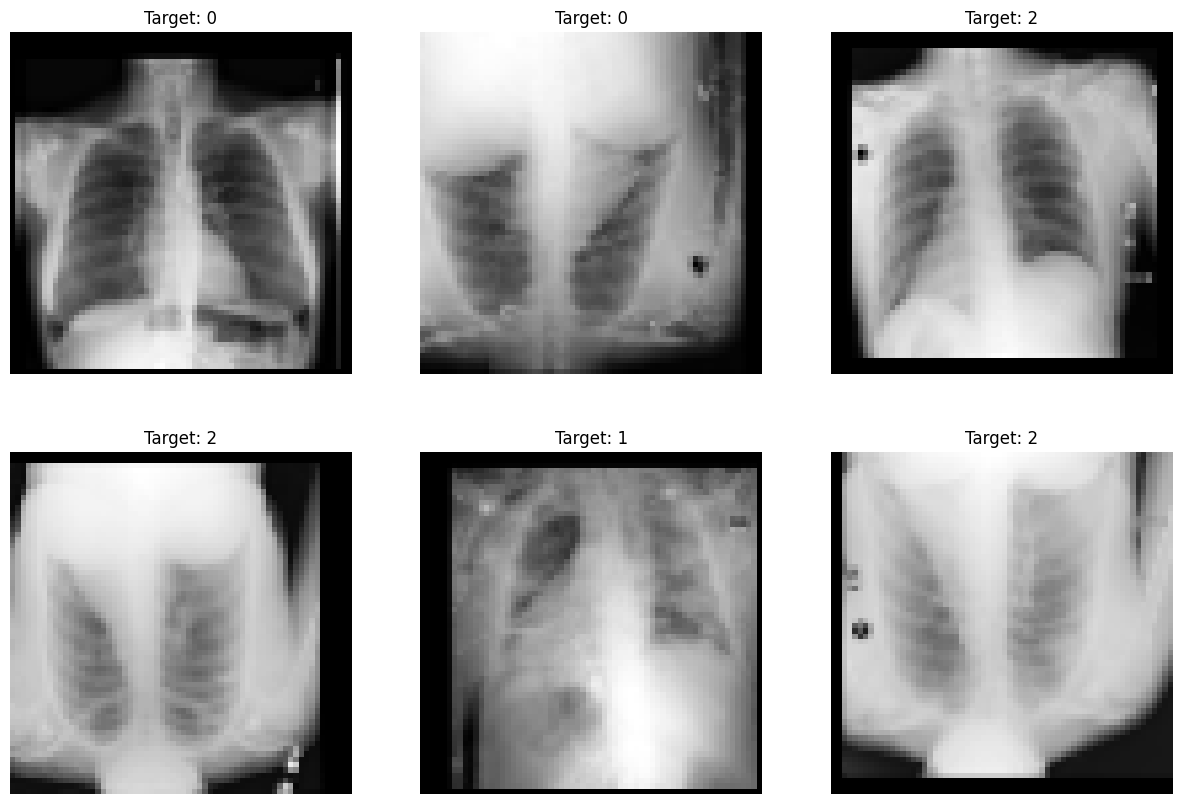

In [41]:
#Displaying images to see effect of preprocessing
#Fetching one batch from the dataset
images, target = next(iter(train_dataset))

#Converting the tensorflow tensors to numpy arrays for visualization
images = images.numpy()
target = target.numpy()

##Normalizing the images to the range [0, 1]
images = (images - np.min(images)) / (np.max(images) - np.min(images))

#Selectnig 6 random indices from the batch
random_indices = np.random.choice(len(images), size=6, replace=False)

#Plotting the selected images
plt.figure(figsize=(15, 10))

for i, idx in enumerate(random_indices):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[idx], cmap='gray')
    plt.title(f"Target: {target[idx]}")
    plt.axis('off')

plt.show()

In [51]:
#Input layer
input_layer = Input(shape=(64, 64, 1))

#Convolutional Block 1
x = Conv2D(32, (3, 3), activation = 'relu', kernel_regularizer=l2(0.001))(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size = (2, 2))(x)

#Convolutional Block 2
x = Conv2D(64, (3, 3), activation = 'relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size = (2, 2))(x)

#Convolutional Block 3
x = Conv2D(128, (3, 3), activation = 'relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size = (2, 2))(x)

#Convolutional Block 4
x = Conv2D(256, (3, 3), activation = 'relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size = (2, 2))(x)

#Convolutional Block 5
#x = Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
#x = BatchNormalization()(x)
#x = MaxPooling2D(pool_size=(2, 2))(x)

#Flattening the output before fully connected layers
x = Flatten()(x)

#Fully Connected Layer 1
x = Dense(512, activation = 'relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

#Fully Connected Layer 2
x = Dense(256, activation = 'relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

#Output Layer
output_layer = Dense(4, activation = 'softmax')(x)

#Creating the model
model = Model(inputs = input_layer, outputs = output_layer)

#Printing model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 4, 4, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 1,046,916 (3.99 MB)

 Trainable params: 1,045,956 (3.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [52]:
#Compiling model
model.compile(optimizer = Adam(learning_rate = 0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [53]:
#Automatic saving of weights and best model
checkpoint = callbacks.ModelCheckpoint(filepath = 'best_model.keras', monitor = 'val_loss', save_best_only = True, save_weights_only = False, mode = 'min', save_freq = 'epoch')

#Automatic learning rate reduction
lr_plateau = callbacks.ReduceLROnPlateau(monitor = 'val_loss', patience = 3, factor = 0.1, verbose = 2, mode = 'min')

#Automatic stopping of training if the model does not evolve anymore
early_stp = callbacks.EarlyStopping(monitor='val_loss', patience = 4, mode = 'min', restore_best_weights = True)

In [48]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(64, 64, 64, 1)
(64,)


In [49]:
for images, labels in val_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(64, 64, 64, 1)
(64,)


In [54]:
import time
#Setting timer
start_time = time.time()

#Fitting model
history = model.fit(train_dataset, epochs = 100, validation_data = val_dataset, callbacks = [early_stp, lr_plateau, checkpoint])

#Calculating time the modelling took
model_time = (time.time() - start_time)/60

Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.5574 - loss: 2.5624 - val_accuracy: 0.2842 - val_loss: 3.7215 - learning_rate: 0.0010
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6895 - loss: 1.7905 - val_accuracy: 0.3180 - val_loss: 2.3951 - learning_rate: 0.0010
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7358 - loss: 1.4308 - val_accuracy: 0.4770 - val_loss: 1.8246 - learning_rate: 0.0010
Epoch 4/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7753 - loss: 1.1664 - val_accuracy: 0.3433 - val_loss: 2.8060 - learning_rate: 0.0010
Epoch 5/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7970 - loss: 0.9873 - val_accuracy: 0.6693 - val_loss: 1.1780 - learning_rate: 0.0010
Epoch 6/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8132 - loss: 0.8746 - val_accuracy: 0.6487 - val_loss: 1.1011 - learning_rate: 0.0010
Epoch 7/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8

In [55]:
#Saving model
model.save('/content/drive/MyDrive/cnn_GradCAM_v2_augmented_grey_full_resized.keras')

In [ ]:
#Loading model
model = tf.keras.models.load_model('/content/drive/MyDrive/cnn_GradCAM_v2_augmented_grey_full.keras')

In [56]:
#Modelling Time
print("Model: --- %s minutes ---" % model_time)

Model: --- 9.075985236962635 minutes ---


In [57]:
#Retrieving probabilities returned by the model
y_prob = model.predict(val_dataset, batch_size = 64)

#Class prediction
y_pred = tf.argmax(y_prob, axis=-1).numpy()

67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [58]:
y_val = []

#Iterating through the validation dataset to collect true labels
for _, labels in val_dataset:
    y_val.extend(labels.numpy())

#Converting the list to numpy array
y_val = np.array(y_val)

In [59]:
#Showing accuracy score
print('Accuracy:\n', accuracy_score(y_val, y_pred))

#Showing confusion matrix
print('Confusion Matrix:\n', confusion_matrix(y_val, y_pred))

#Showing classification report
print('Classification Report:\n', classification_report(y_val, y_pred))

Accuracy:
 0.9149539333805812
Confusion Matrix:
 [[1941   11   82    4]
 [  44  628   51    0]
 [ 134    6 1063    0]
 [  25    0    3  241]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      2038
           1       0.97      0.87      0.92       723
           2       0.89      0.88      0.89      1203
           3       0.98      0.90      0.94       269

    accuracy                           0.91      4233
   macro avg       0.94      0.90      0.92      4233
weighted avg       0.92      0.91      0.91      4233



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

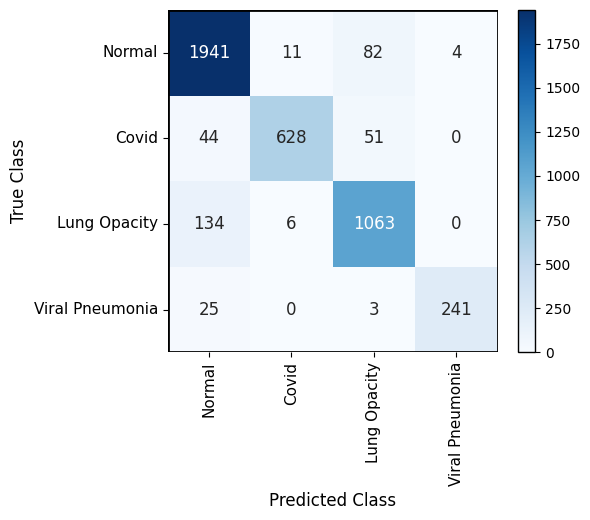

In [60]:
#Building confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred)

#Labelling classes
labels = ['Normal', 'Covid', 'Lung Opacity', 'Viral Pneumonia']

#Plotting the confusion matrix
plt.figure(figsize=(6, 5.3))
heatmap = sns.heatmap(conf_matrix, annot = True, fmt = 'g', cmap = 'Blues', xticklabels = labels, yticklabels = labels, annot_kws={"size": 12}, cbar=True)

#Adding a box around the confusion matrix
plt.gca().add_patch(plt.Rectangle((0, 0), len(labels), len(labels),
                                    fill=False, edgecolor='black', linewidth=2))

#Adding a box around the color bar
colorbar = heatmap.collections[0].colorbar
colorbar.outline.set_visible(True)  # Make sure the outline is visible
colorbar.outline.set_edgecolor('black')  # Set the color of the box
colorbar.outline.set_linewidth(1)  # Set the width of the box

plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

#Saving the figure locally
plt.savefig('confusion_matrix_CNN_grey_full_resized.png', dpi=300, bbox_inches='tight')

#Downloading the saved image
files.download('confusion_matrix_CNN_grey_full_resized.png')

#Showing the plot
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

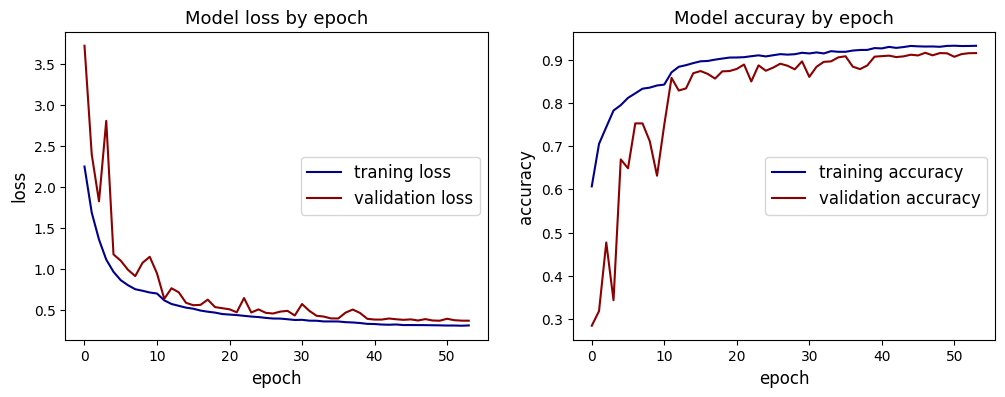

In [61]:
#Displaying model loss and accuracy per epoch
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(history.history['loss'], color = 'darkblue')
plt.plot(history.history['val_loss'], color = 'darkred')
plt.title('Model loss by epoch', fontsize=13)
plt.ylabel('loss', fontsize=12)
plt.xlabel('epoch', fontsize=12)
plt.legend(['traning loss', 'validation loss'], loc='right', fontsize=12)

plt.subplot(122)
plt.plot(history.history['accuracy'], color = 'darkblue')
plt.plot(history.history['val_accuracy'], color = 'darkred')
plt.title('Model accuray by epoch', fontsize=13)
plt.ylabel('accuracy', fontsize=12)
plt.xlabel('epoch', fontsize=12)
plt.legend(['training accuracy', 'validation accuracy'], loc='right', fontsize=12)

#Saving the figure locally
plt.savefig('model_performance_cnn_augmented_grey_full_resized.png', dpi=300, bbox_inches='tight')

#Downloading the saved image
files.download('model_performance_cnn_augmented_grey_full_resized.png')

plt.show()

In [62]:
#Creating a dataframe from the training history
results_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Train Loss': history.history['loss'],
    'Val Loss': history.history['val_loss'],
    'Train Accuracy': history.history['accuracy'],
    'Val Accuracy': history.history['val_accuracy']
})

print(results_df)

    Epoch  Train Loss  Val Loss  Train Accuracy  Val Accuracy
0       1    2.248824  3.721542        0.606780      0.284196
1       2    1.686468  2.395065        0.705233      0.317978
2       3    1.358753  1.824554        0.744094      0.476967
3       4    1.114594  2.805965        0.782424      0.343255
4       5    0.965597  1.177958        0.794944      0.669265
5       6    0.863413  1.101058        0.811717      0.648713
6       7    0.802359  0.989928        0.822289      0.752658
7       8    0.753315  0.913243        0.833038      0.752658
8       9    0.734791  1.074928        0.835459      0.711316
9      10    0.713449  1.148900        0.840420      0.631467
10     11    0.700986  0.946085        0.842547      0.749587
11     12    0.617840  0.636543        0.870895      0.858020
12     13    0.573338  0.765405        0.883711      0.828727
13     14    0.551069  0.715726        0.887491      0.833688
14     15    0.528922  0.587788        0.892275      0.868887
15     1

In [63]:
#Grad-CAM (Gradient-weighted Class Activation Mapping) technique to visualize which parts of an input image are important for a model’s predictions.
#Function to generate Grad-CAM heatmaps
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    #The grad_model is created by specifying the model's inputs and outputs. The outputs include both the activations from the last convolutional layer
    #and the final model output (predictions). This allows us to compute the gradients of the model's predictions with respect to the convolutional layer's outputs.
    grad_model = tf.keras.models.Model(

        #last_conv_layer_name: The name of the last convolutional layer in the model. This activation map (output of this layer) is the basis for the generated heatmap.
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)

        #Computing the index of the class that has the highest predicted probability for the input image.
        top_pred_index = tf.argmax(preds[0])

        #Extracting the predicted output for the class identified by top_pred_index from the model's predictions.
        top_class_channel = preds[:, top_pred_index]

    #Calculating the gradients of the loss with respect to the convolutional layer's outputs.
    grads = tape.gradient(top_class_channel, conv_outputs)

    #Computing the mean of the gradients across the spatial dimensions (height and width) for each filter (channel).
    #pooled_grads, will have a shape of (num_filters,), meaning it contains one value per filter representing its importance in the final prediction.
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #Weighting the output feature map of the last conv layer by the gradients.
    #Extracting the feature map from the last convolutional layer's output.
    conv_outputs = conv_outputs[0]

    #Performing a matrix multiplication between the feature map (conv_outputs) and the pooled gradients (pooled_grads), and reshaping to add a new axis.
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    #Removing dimensions of size 1 from the tensor.
    heatmap = tf.squeeze(heatmap)

    #Applying a ReLU activation to remove negative values, ensuring that only the important regions are highlighted. Normalizing data.
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [64]:
#Function to display gradcam
def display_gradcam(img, heatmap, alpha = 0.4):
    #Resizing heatmap to match the image size
    heatmap = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize((img.shape[1], img.shape[0])))

    #Applying the colormap
    colormap = plt.get_cmap('jet')

    #Normalizing heatmap to range [0, 1] for colormap application
    normalized_heatmap = heatmap / np.max(heatmap)

    #Applying the colormap
    colored_heatmap = colormap(normalized_heatmap)

    #Convert to RGB by discarding the alpha channel
    colored_heatmap = (colored_heatmap[..., :3] * 255).astype(np.uint8)

    #Converting original image to a PIL image for blending
    img_squeezed = np.squeeze(img)
    img_pil = Image.fromarray((img_squeezed * 255).astype(np.uint8))

    #Converting grayscale to RGB
    img_rgb = img_pil.convert("RGB")

    #Creating a PIL image for the heatmap
    heatmap_image = Image.fromarray(colored_heatmap)

    #Blending heatmap and original image
    superimposed_img = Image.blend(img_rgb, heatmap_image, alpha)

    #Normalizing for display
    return np.array(superimposed_img) / 255

In [65]:
#Function to create a saliency map
def create_saliency_map(model, img_array):

    #Computing gradients with respect to the input image.
    #Createing a GradientTape context to record operations for automatic differentiation.
    with tf.GradientTape() as tape:

        #Watching the input image array so that we can compute gradients with respect to it.
        tape.watch(img_array)

        #Returning an array of probabilities for each class.
        preds = model(img_array)

        #Getting the predicted class index
        class_index = tf.argmax(preds[0])

        #Extracting the model's output probability for the predicted class.
        class_output = preds[0][class_index]

    #Computing the gradient of the predicted class output with respect to the input image.
    #The gradient tells how much a small change in each pixel value of the image would change the predicted class score.
    grads = tape.gradient(class_output, img_array)

    #Taking the absolute value of the gradients to focus on regions of high sensitivity.
    saliency = tf.abs(grads[0])

    #Normalizing the saliency map so that the values are between 0 and 1.
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency))
    return saliency.numpy()

In [66]:
#Checking names of layer
for layer in model.layers:
    print(layer.name)

input_layer_3
conv2d_15
batch_normalization_15
max_pooling2d_15
conv2d_16
batch_normalization_16
max_pooling2d_16
conv2d_17
batch_normalization_17
max_pooling2d_17
conv2d_18
batch_normalization_18
max_pooling2d_18
flatten_3
dense_9
dropout_6
dense_10
dropout_7
dense_11


0
0
0
0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

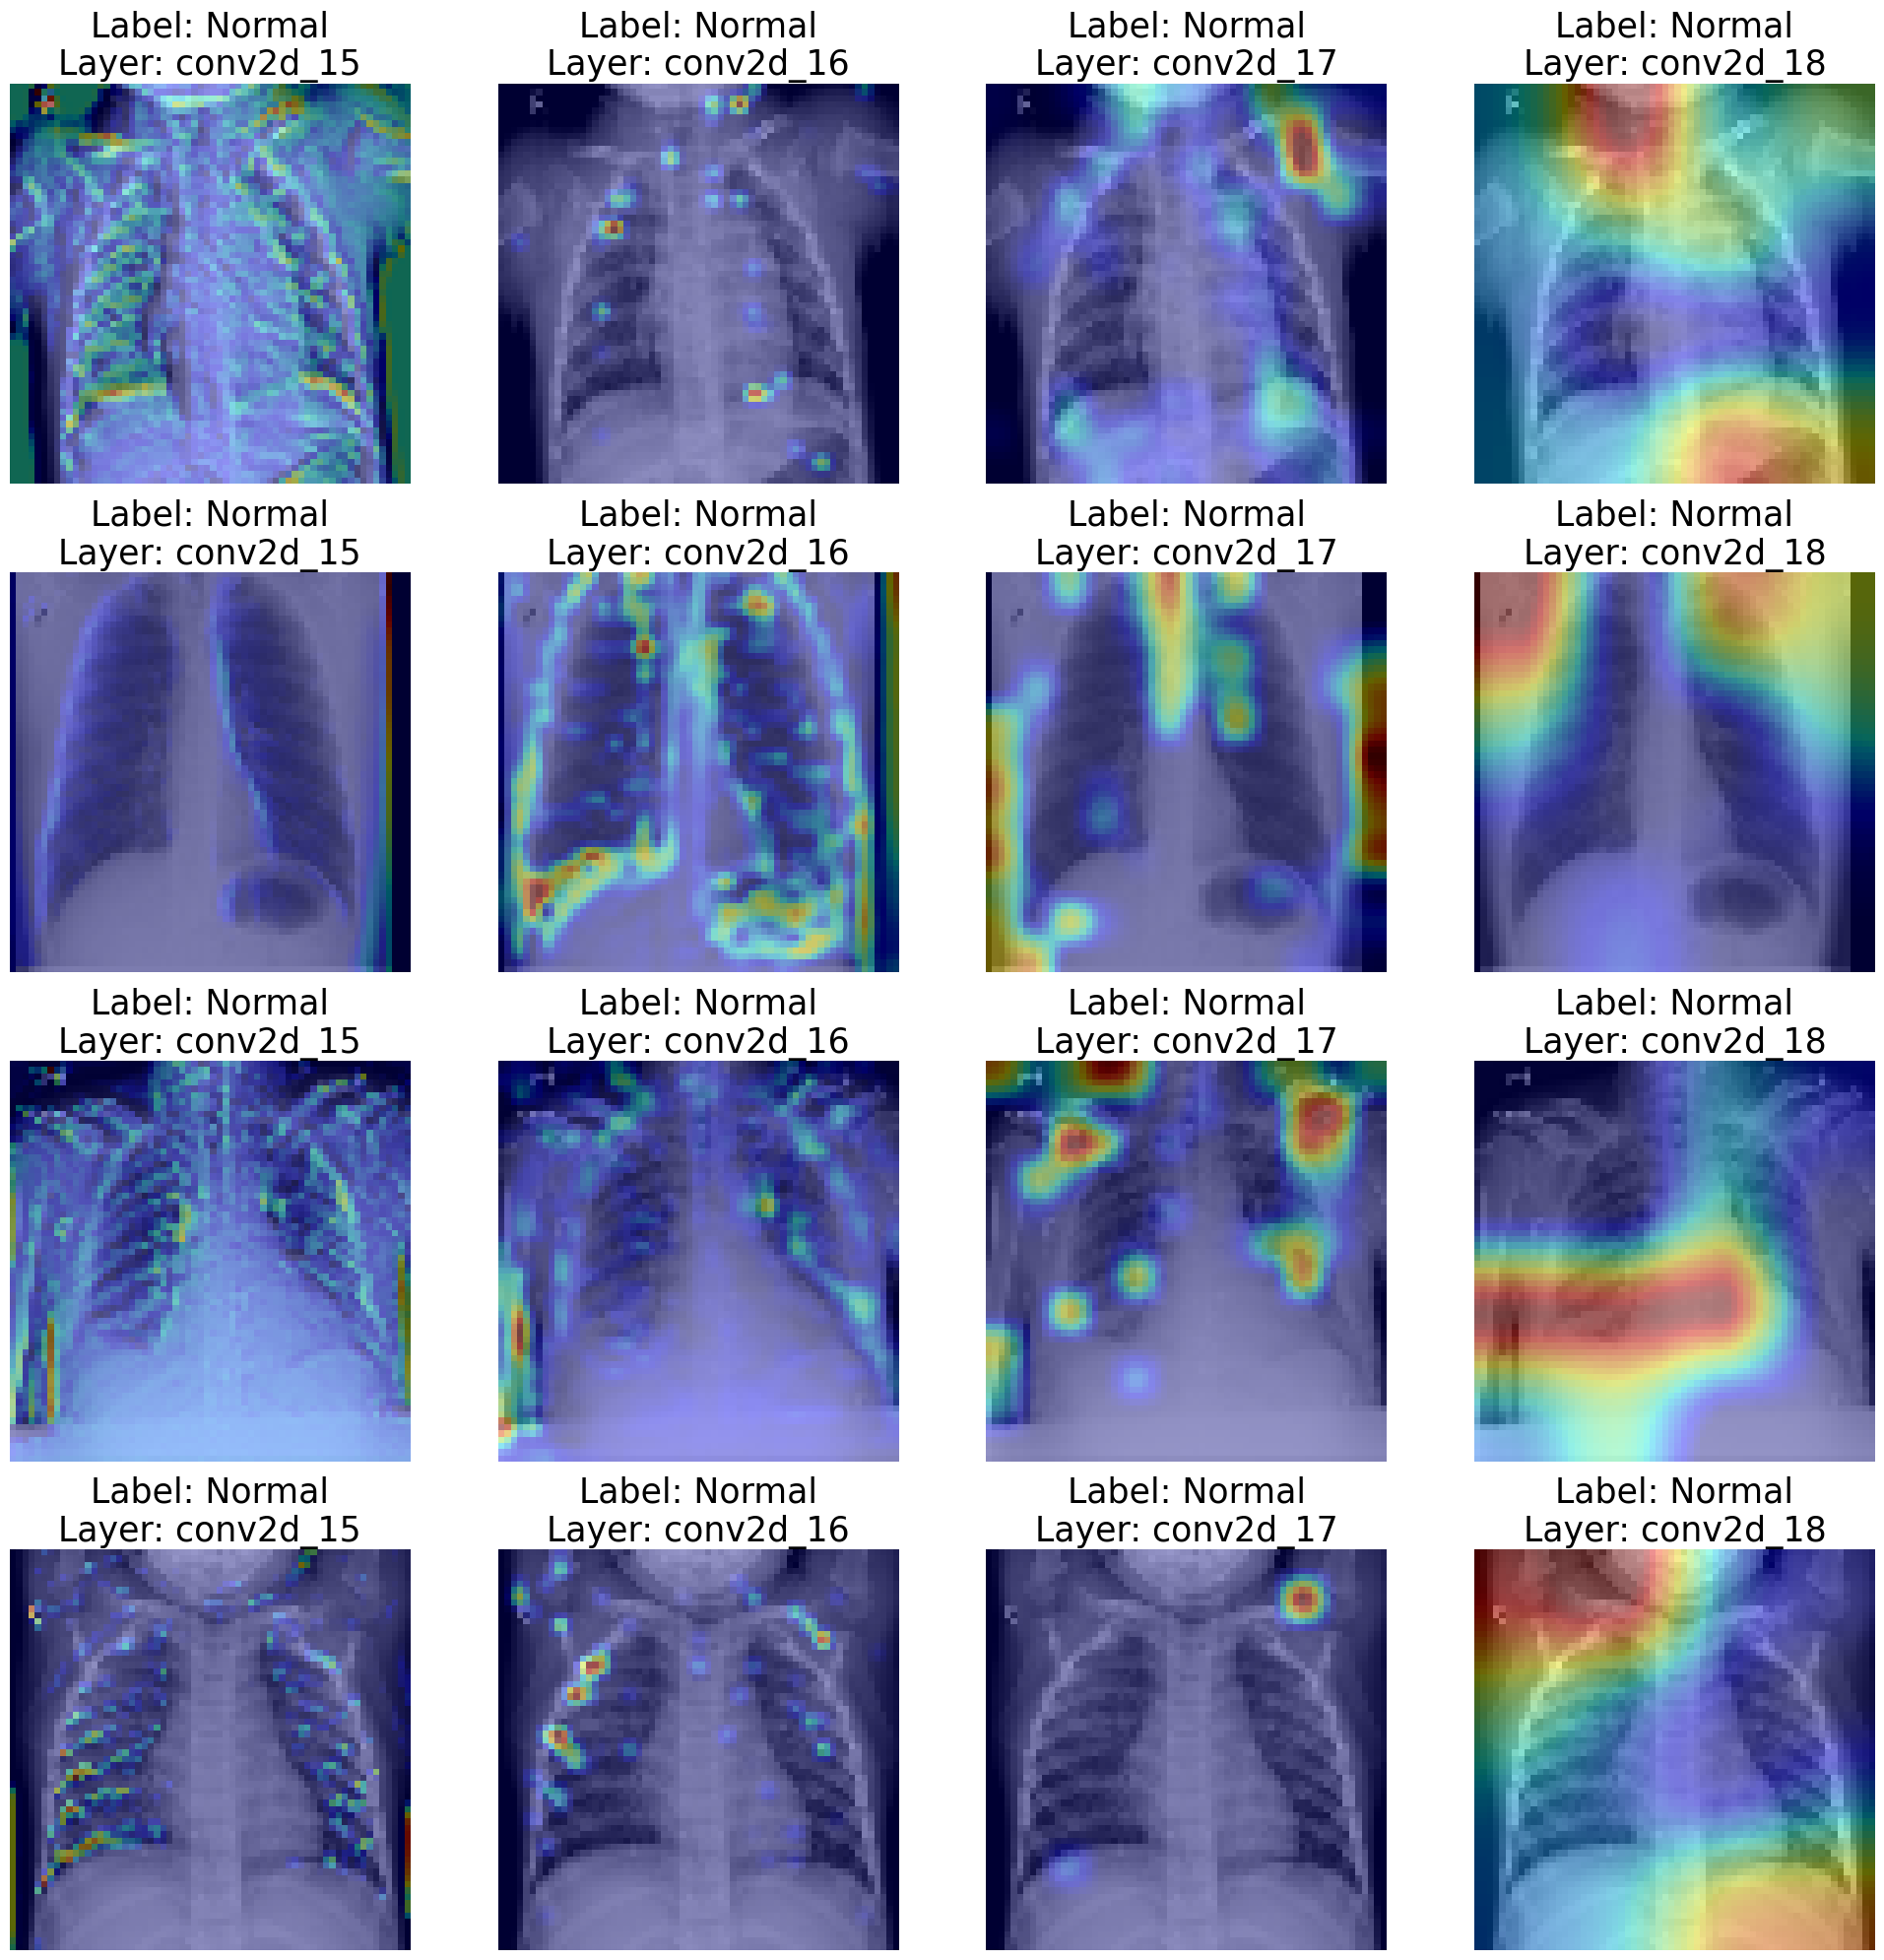

In [68]:
#Function to retrieve random images from the val_dataset
def get_random_images_from_dataset(dataset, num_images=4):
    images = []
    labels = []

    #Converting the dataset to a list for easier indexing
    dataset_list = list(dataset)

    #Randomly select indices
    random_indices = random.sample(range(len(dataset_list)), num_images)

    #Retrieving images and labels based on random indices
    for i in random_indices:
        img, label = dataset_list[i]
        images.append(img)
        labels.append(label)

    return images, labels

#Getting four random images and their labels from val_dataset
random_images, random_labels = get_random_images_from_dataset(val_dataset, num_images=4)

#Setting conv layers and cases
conv_layer_names = ['conv2d_15', 'conv2d_16', 'conv2d_17', 'conv2d_18']
cases = ['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia']

plt.figure(figsize=(20, 20))

#Looping through each image and its corresponding label
for img in range(len(random_images)):
    #Getting first image from batch
    sample_img = random_images[img][0]
    #Getting label index
    sample_label = np.argmax(random_labels[img][0])
    print(sample_label)

    #Ensuring sample_img is in the correct format
    sample_img_expanded = tf.expand_dims(sample_img, axis = 0)

    #Normalizing the sample image
    #sample_img = (sample_img - np.min(sample_img)) / (np.max(sample_img) - np.min(sample_img))

    #Looping through each convolutional layer
    for layer in range(len(conv_layer_names)):
        layer_name = conv_layer_names[layer]
        # Getting heatmap for the current layer and creating gradcam image
        heatmap = get_gradcam_heatmap(model, sample_img_expanded, layer_name)
        gradcam_image = display_gradcam(sample_img.numpy(), heatmap)

        # Clipping the values manually for display
        gradcam_image = np.clip(gradcam_image, 0, 1)

        # Plotting gradcam images
        plt.subplot(4, 4, img * 4 + layer + 1)
        plt.title(f"Label: {cases[sample_label]}\nLayer: {layer_name}", fontsize = 25)
        plt.imshow(gradcam_image)
        plt.axis('off')

#Adjusting layout
plt.tight_layout()

#Saving and downloading the plot
plt.savefig("gradcam_random_cnn_augmented_grey_full_resized.png", dpi = 300, bbox_inches = 'tight')
files.download("gradcam_random_cnn_augmented_grey_full_resized.png")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
0
Normal
Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1
COVID
COVID
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2
Lung_Opacity
Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3
Viral Pneumonia
Viral Pneumonia


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

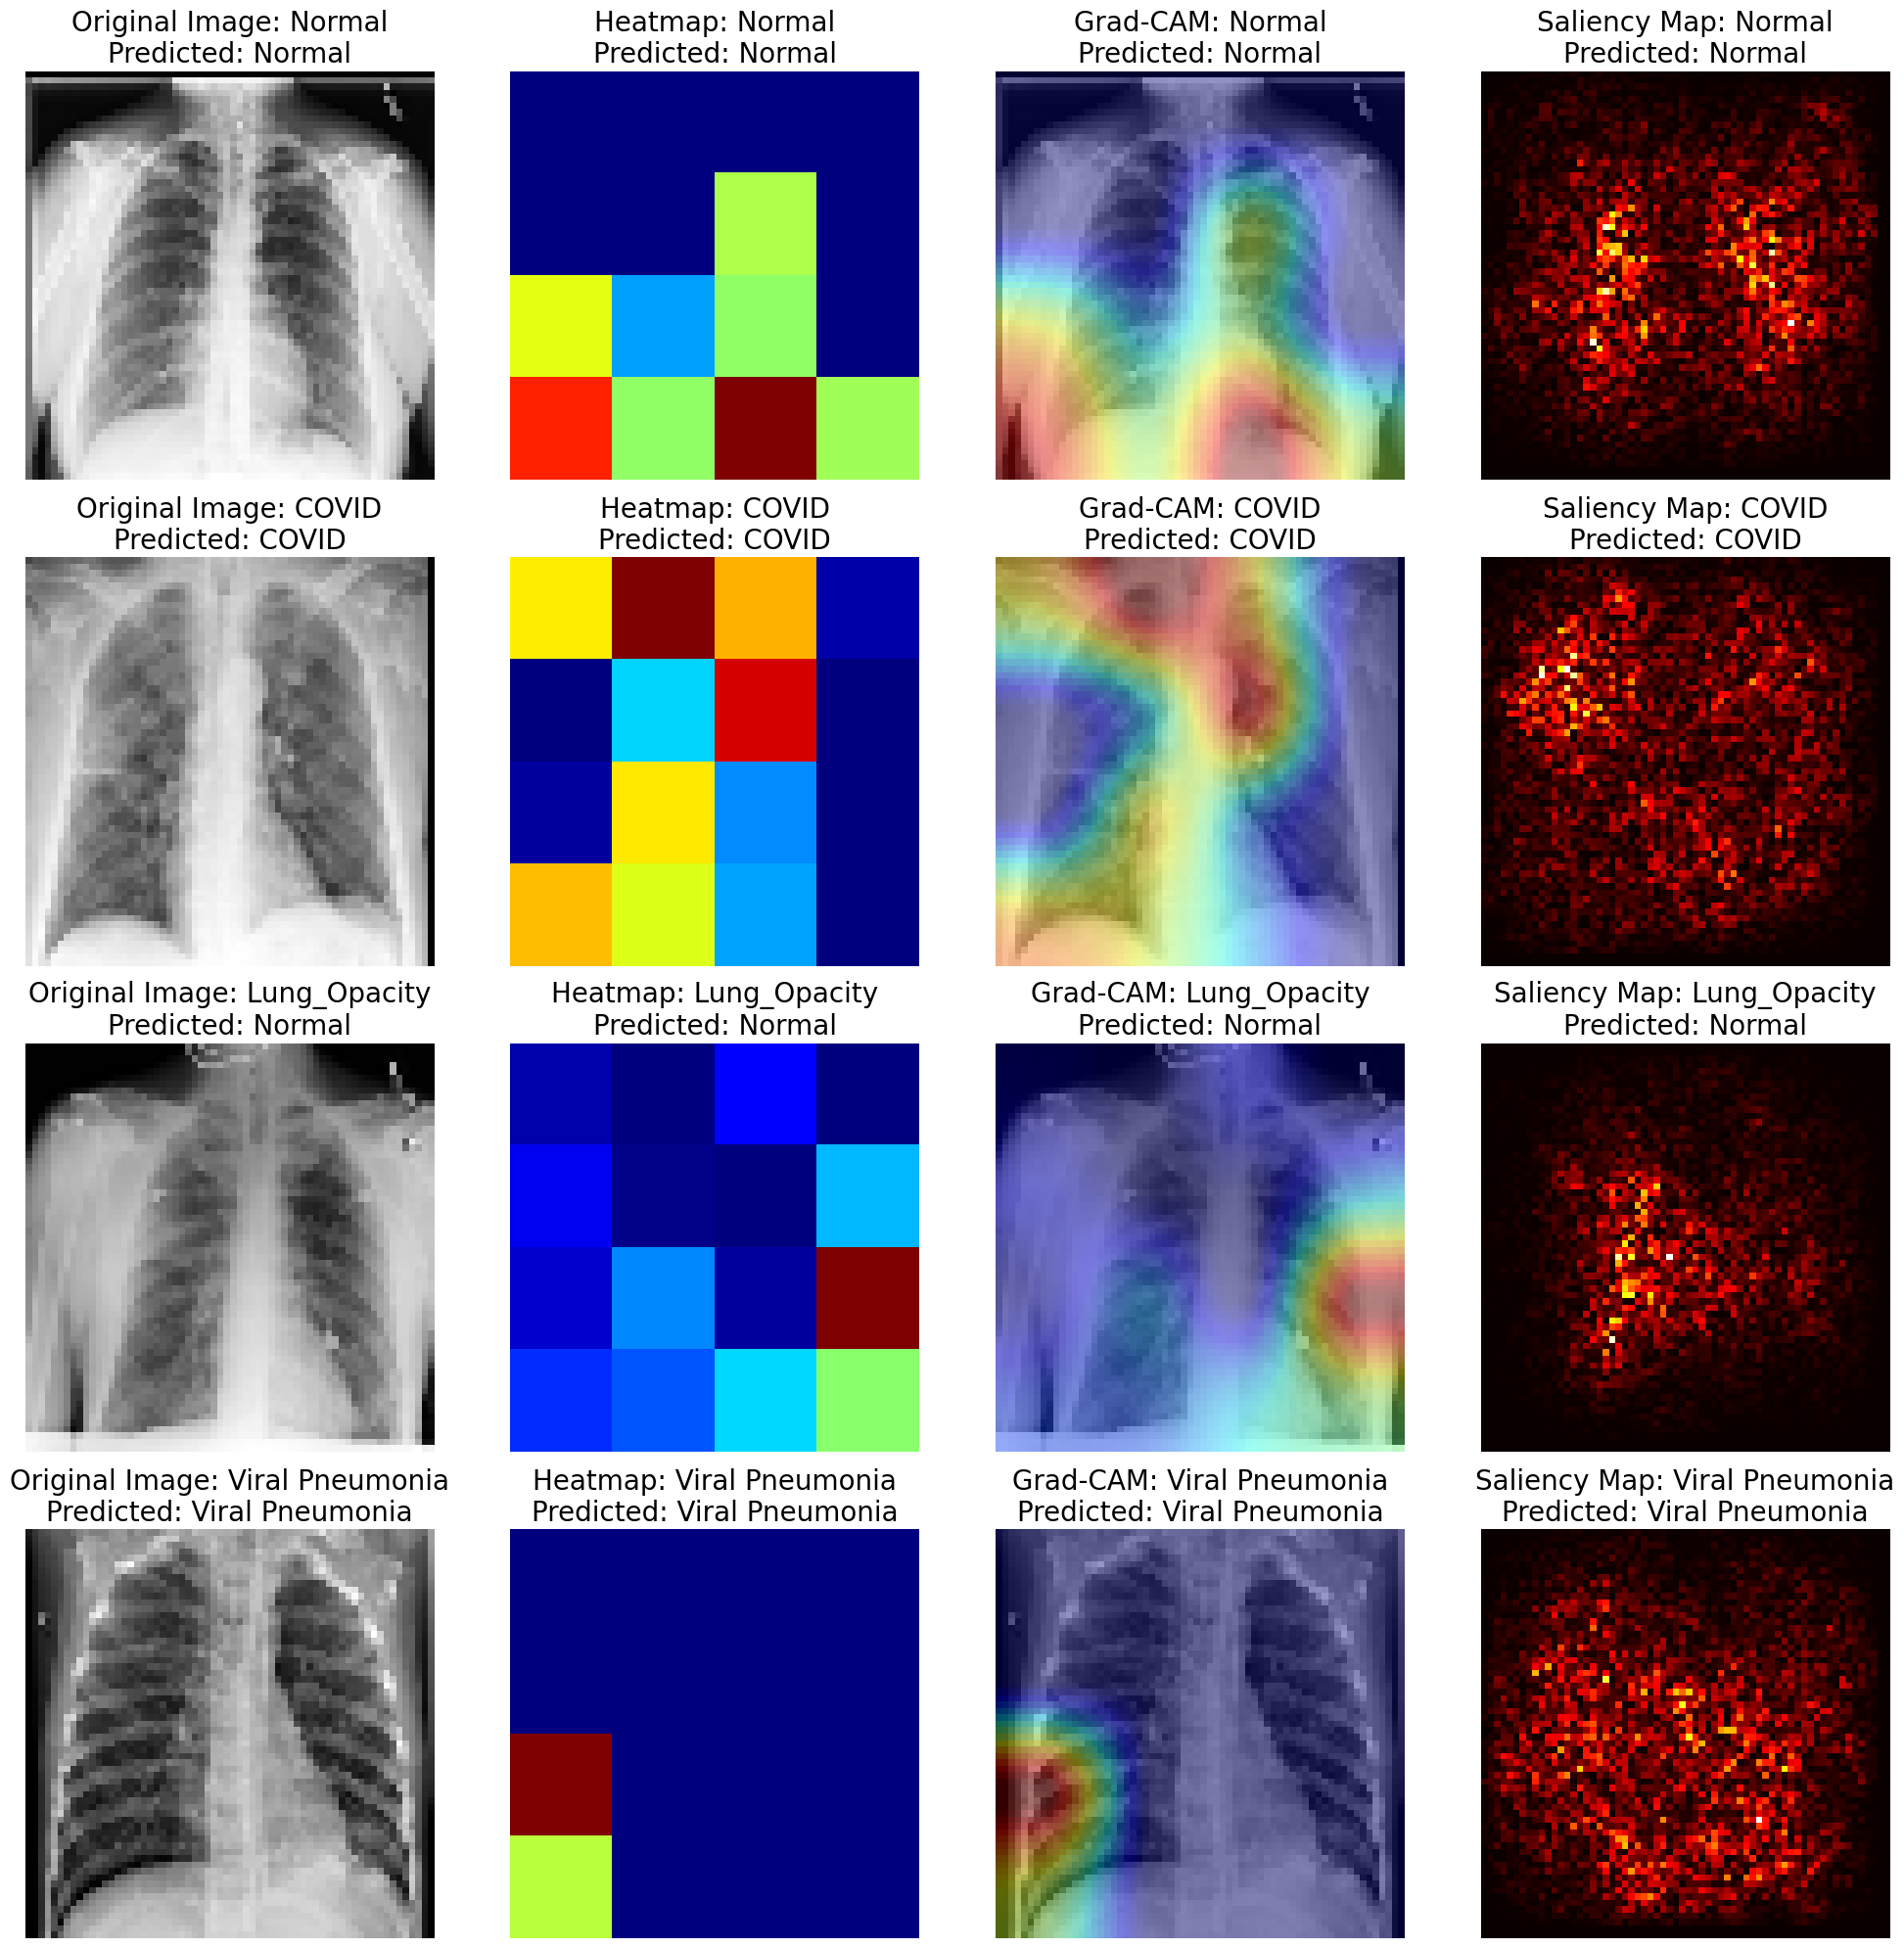

In [69]:
#Selecting 4 cases from the validation dataset
cases = ["Normal", "COVID", "Lung_Opacity", "Viral Pneumonia"]

#Specifying sample images by labels
image_paths1 = [
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/images/Normal-21.png",
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/COVID/images/COVID-31.png",
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/Lung_Opacity/images/Lung_Opacity-3.png",
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/Viral Pneumonia/images/Viral Pneumonia-9.png"
]

mask_paths1 = [
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-21.png",
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/COVID/masks/COVID-31.png",
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/Lung_Opacity/masks/Lung_Opacity-3.png",
    "/content/covid19_radiography/COVID-19_Radiography_Dataset/Viral Pneumonia/masks/Viral Pneumonia-9.png"
]

target1 = [0, 1, 2, 3]

images1 = []

#Preprocessing images
for i in range(len(image_paths1)):
  img, _ = load_and_preprocess_image_and_mask_val(image_paths1[i], mask_paths1[i], target1[i])
  images1.append(img)

plt.figure(figsize=(20, 20))

#Plotting
for idx in range(len(images1)):

    sample_img = images1[idx]
    sample_label = target1[idx]

    #EnsureConverting sample_img from tensor to numpy for further processing
    sample_img = sample_img.numpy()

    #Adding a new dimension to match the model's expected input shape (1, 240, 240, 1)
    sample_img_expanded = tf.expand_dims(sample_img, axis=0)
    sample_img = np.squeeze(sample_img)

    #Normalizing the images to the range [0, 1]
    sample_img = (sample_img - np.min(sample_img)) / (np.max(sample_img) - np.min(sample_img))

    #Getting the heatmap and prepare display
    heatmap = get_gradcam_heatmap(model, sample_img_expanded, 'conv2d_18')
    gradcam_image = display_gradcam(sample_img, heatmap)

    #Getting the saliency map
    saliency_map = create_saliency_map(model, sample_img_expanded)

    #Getting the model's prediction
    predictions = model.predict(sample_img_expanded)
    predicted_label_index = np.argmax(predictions, axis=1)[0]
    predicted_label = cases[predicted_label_index]

    #Manually clip values to ensure they fall within [0, 1] for display
    gradcam_image = np.clip(gradcam_image, 0, 1)
    saliency_map = np.clip(saliency_map, 0, 1)
    sample_img = np.clip(sample_img, 0, 1)
    heatmap = np.clip(heatmap, 0, 1)

    print(sample_label)
    print(cases[sample_label])
    print(predicted_label)

    #Plotting original image, heatmap, saliency map and grad-cam
    plt.subplot(4, 4, 4 * idx + 1)
    plt.title(f"Original Image: {cases[sample_label]}\nPredicted: {predicted_label}", fontsize = 20)
    plt.imshow(sample_img, cmap = 'gray')
    plt.axis('off')

    plt.subplot(4, 4, 4 * idx + 2)
    plt.title(f"Heatmap: {cases[sample_label]}\nPredicted: {predicted_label}", fontsize = 20)
    plt.imshow(heatmap, cmap='jet')
    plt.axis('off')

    plt.subplot(4, 4, 4 * idx + 3)
    plt.title(f"Grad-CAM: {cases[sample_label]}\nPredicted: {predicted_label}", fontsize = 20)
    plt.imshow(gradcam_image, cmap = 'gray')
    plt.axis('off')

    plt.subplot(4, 4, 4 * idx + 4)
    plt.title(f"Saliency Map: {cases[sample_label]}\nPredicted: {predicted_label}", fontsize = 20)
    plt.imshow(saliency_map, cmap='hot')
    plt.axis('off')

#Reducing spaces between images in plot
plt.tight_layout()

#Saving plot
plt.savefig("gradcam_saliency_cnn_augmented_grey_full_resized.png", dpi=300, bbox_inches='tight')

#Downloading plot to local
files.download("gradcam_saliency_cnn_augmented_grey_full_resized.png")

plt.show()